# compute metrics

In [ ]:
%%bash

# Define datasets to iterate over
datasets=("replogle_k562" "replogle_rpe1" "nadig_hepg2" "nadig_jurkat" "norman_combo")
methods=("gears" "cellflow" "scgpt")

# Define splits and fractions to iterate over
splits=(1 2 3)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="../data/preprocessed_${dataset}.h5ad"
    for method in "${methods[@]}"; do
        for split in "${splits[@]}"; do
            split_path="../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl"
            adata_pred_path="../data/${method}/${dataset}/adata_pred_${split}_0.75.h5ad"
            results_path="../data/${method}/${dataset}/results_test_${split}.csv"
            
            python ../scripts/evaluate_pred.py ${adata_path} ${adata_pred_path} ${split_path} ${results_path}
        done
    done
done

## Pert train

In [ ]:
%%bash

# Define datasets to iterate over
datasets=("replogle_k562" "replogle_rpe1" "nadig_hepg2" "nadig_jurkat" "norman_combo")
method="pert_train"
# Define splits and fractions to iterate over
splits=(1 2 3)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="../data/preprocessed_${dataset}.h5ad"
        for split in "${splits[@]}"; do
            split_path="../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl"
            results_path="../data/${method}/${dataset}/results_test_${split}.csv"
            
            python ../scripts/compute_baseline_metrics.py ${adata_path}  ${split_path} ${results_path} "pert_train"
    done
done

## Technical duplicate

In [ ]:
%%bash

# Define datasets to iterate over
datasets=("replogle_k562" "replogle_rpe1" "nadig_hepg2" "nadig_jurkat" "norman_combo")
method="pos_ctrl"
# Define splits and fractions to iterate over
splits=(1 2 3)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="../data/preprocessed_${dataset}.h5ad"
        for split in "${splits[@]}"; do
            split_path="../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl"
            results_path="../data/${method}/${dataset}/results_test_${split}.csv"
            
            python ../scripts/compute_pos_ctrl_metrics.py ${adata_path}  ${split_path} ${results_path}
    done
done

# Results

In [1]:
import scanpy as sc
import pandas as pd
import json
import matplotlib.pyplot as plt

from gfm.helpers import combine_results

model_color_dict = json.load(open("../data/model_color_dict.json", "r"))

import warnings
warnings.filterwarnings('ignore')

## one-gene perturbation

In [2]:
model_names = ["GFM", "GEARS", "CellFlow", "scGPT", "Linear"]
ds_list = ['replogle_k562', 'replogle_rpe1', 'nadig_hepg2', 'nadig_jurkat']
split_list = ['1', '2', '3']

results = []
test_results_list = []
for ds in ds_list:
    result_dict = {
        'GFM': [f"../data/gfm/{ds}/split_{split}/results_test_gfm_go+gwps+ppi_gat.csv" for split in split_list],
        'Dup': [f"../data/pos_ctrl/{ds}/results_test_{split}.csv" for split in split_list],
        'Linear': [f"../data/linear_model/{ds}/results_test_{split}.csv" for split in split_list],
        'CellFlow': [f"../data/cellflow/{ds}/results_test_{split}.csv" for split in split_list],
        'GEARS': [f"../data/gears/{ds}/results_test_{split}.csv" for split in split_list],
        'scGPT': [f"../data/scgpt/{ds}/results_test_{split}.csv" for split in split_list],
        'Perturb train': [f"../data/pert_train/{ds}/results_test_{split}.csv" for split in split_list]
    }
    res_dict = combine_results(result_dict, baseline_model="Perturb train", return_test_results=True)
    result_combined = res_dict['combined_results']
    result_combined['dataset'] = ds
    results.append(result_combined)

    test_results = res_dict['test_results']
    test_results['dataset'] = ds
    test_results_list.append(test_results)
    
results_all = pd.concat(results, ignore_index=True)
test_results_all = pd.concat(test_results_list, ignore_index=True)

In [3]:
from matplotlib.patches import Patch
def plot_metric_boxplot_grid(
    df,
    test_df,
    datasets,
    metrics,
    figsize=None,
    model_color_dict=None,
    save_path=None,
    showfliers=False,
    baseline_zero_line=True,
    reference_model='GFM',
):
    """
    Create a grid of metric boxplots with metrics as rows and datasets as columns.

    This mirrors `plot_metrics_grid` layout, but each subplot is a boxplot
    over per-split values (styled like `plot_delta_metrics_boxplot`).
    """
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    df = df.copy()

    metric_labels = {
        'mse': 'Δ MSE',
        'pearson': 'Δ Pearson r',
        'pearson_delta': 'Pearson Delta',
        'spearman': 'Δ Spearman rho',
        'mmd': 'Δ MMD',
        'w2d': 'Δ 2-WD',
        'e_distance': 'Δ E-Distance',
    }

    n_metrics = len(metrics)
    n_datasets = len(datasets)

    if figsize is None:
        figsize = (8, 10)

    fig, axes = plt.subplots(n_metrics, n_datasets, figsize=figsize, squeeze=False)

    model_name_list = df['model'].unique().tolist()

    for i, metric in enumerate(metrics):
        for j, dataset in enumerate(datasets):
            ax = axes[i, j]
            to_plot = df[df['dataset'] == dataset].copy()

            if metric in ['mmd', 'w2d', 'e_distance'] and 'model' in to_plot.columns:
                to_plot = to_plot[~to_plot['model'].isin(['Additive', 'Linear'])].copy()


            model_order = list(pd.unique(to_plot['model']))

            sns.boxplot(
                data=to_plot,
                x='model',
                y=metric,
                hue='model',
                order=model_order,
                hue_order=model_order,
                dodge=False,
                fill=True,
                width=0.6,
                linewidth=0.5,
                fliersize=0.0 if not showfliers else 2.0,
                palette=model_color_dict,
                saturation=1,
                ax=ax,
            )

            if baseline_zero_line:
                ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)

            # Match delta-metric style by hiding x labels in dense subplot grids.
            ax.set_xticklabels([])
            ax.set_xlabel('')

            if i == 0:
                ax.set_title(dataset.replace('_', ' ').title(), fontweight='bold')

            if j == 0:
                ax.set_ylabel(metric_labels.get(metric, metric))
            else:
                ax.set_ylabel('')

            # Rescale each subplot to whisker range (exclude outliers), similar to
            # `plot_delta_metrics_boxplot`.
            groups = to_plot.groupby('model', observed=True)[metric]
            whisker_min = float('inf')
            whisker_max = float('-inf')
            model_top = {}

            for model_name, group_data in groups:
                data = group_data.dropna()
                if len(data) == 0:
                    continue
                q1 = data.quantile(0.25)
                q3 = data.quantile(0.75)
                iqr = q3 - q1
                lower_bound = q1 - 1.5 * iqr
                upper_bound = q3 + 1.5 * iqr
                actual_lower = data[data >= lower_bound].min()
                actual_upper = data[data <= upper_bound].max()
                whisker_min = min(whisker_min, actual_lower)
                whisker_max = max(whisker_max, actual_upper)
                model_top[model_name] = actual_upper

            if whisker_min != float('inf') and whisker_max != float('-inf'):
                if metric in ['pearson', 'pearson_delta', 'spearman']:
                    whisker_max = min(whisker_max, 1.0)
                y_range = whisker_max - whisker_min
                if y_range == 0:
                    y_range = max(abs(whisker_max), 1e-3)
                padding = 0.1 * y_range
                ax.set_ylim(whisker_min - padding, whisker_max + padding)
            else:
                y_range = 1.0

            # Add significance annotations like plot_delta_metrics_boxplot.
            if test_df is not None and not test_df.empty:
                metric_results = test_df[
                    (test_df['dataset'] == dataset) &
                    (test_df['metric'] == metric)
                ]

                if not metric_results.empty:
                    for model_idx, model_name in enumerate(model_order):
                        if model_name == reference_model:
                            continue

                        sig_row = metric_results[metric_results['comparison_model'] == model_name]
                        if sig_row.empty:
                            continue

                        sig_star = sig_row.iloc[0]['significance']
                        if sig_star == 'ns':
                            continue

                        y_pos = model_top.get(model_name, np.nan)
                        if pd.isna(y_pos):
                            continue

                        y_pos = y_pos + 0.02 * y_range
                        ymin, ymax = ax.get_ylim()
                        if y_pos >= ymax:
                            ax.set_ylim(ymin, y_pos + 0.05 * y_range)

                        ax.text(
                            model_idx + 0.1,
                            y_pos,
                            sig_star,
                            ha='center',
                            va='bottom',
                            fontweight='bold',
                        )

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    legend_elements = [Patch(facecolor=model_color_dict[model_name], label=model_name) for model_name in model_name_list]

    fig.legend(
        handles=legend_elements,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.05),
        ncol=len(model_name_list),
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

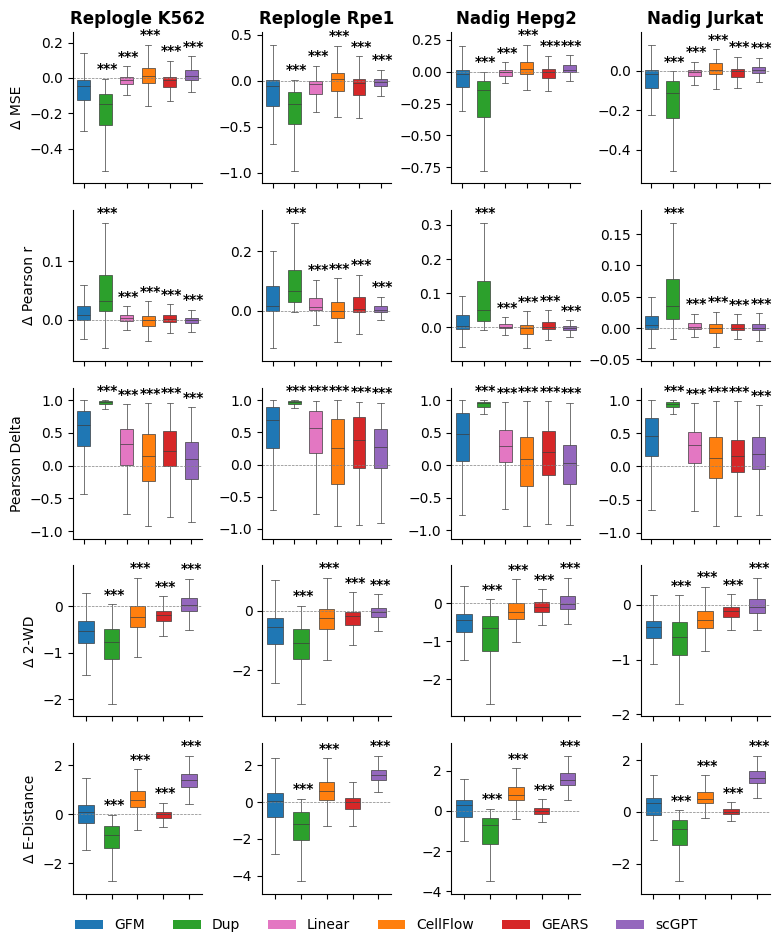

In [4]:
plot_metric_boxplot_grid(
    results_all,
    test_results_all,
    datasets=ds_list,
    metrics=['mse', 'pearson', 'pearson_delta', 'w2d', 'e_distance'],
    model_color_dict=model_color_dict,
    save_path="../data/final_plots/test_metrics_boxplot_grid.pdf"
)

In [4]:
from gfm.visualization import get_adata_condition_subset, plot_delta_expression_boxplot_model, plot_umap_by_model

Here, we show EIF2S1 knockdown from K562 in the test set from split 1 as the example.

In [ ]:
split = 1
dataset = 'replogle_k562'
condition = 'EIF2S1+ctrl'
adata_paths = {
    "Truth": f"../data/preprocessed_{dataset}.h5ad",
    "GFM": f"../data/gfm/{dataset}/split_{split}/adata_pred_gfm_go+gwps+ppi_gat.h5ad",
    "CellFlow": f"../data/cellflow/{dataset}/adata_pred_{split}.h5ad",
    "GEARS": f"../data/gears/{dataset}/adata_pred_{split}_0.75.h5ad",
    "scGPT": f"../data/scgpt/{dataset}/adata_pred_{split}.h5ad"
}

In [ ]:
adata = get_adata_condition_subset(adata_paths, condition=condition)

In [ ]:
adata.write_h5ad(f"../data/final_plots_data/adata_subset_{dataset}_{condition}_{split}.h5ad")

In [ ]:
adata = sc.read_h5ad(f"../data/final_plots_data/adata_subset_{dataset}_{condition}_{split}.h5ad")

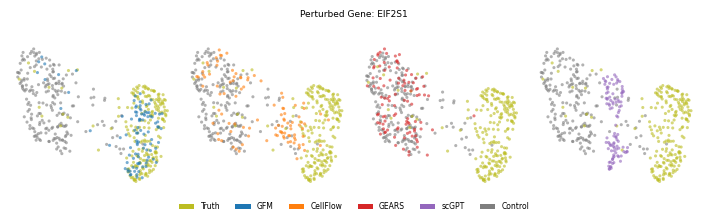

In [ ]:
plot_umap_by_model(adata, adata_paths, model_color_dict, condition=condition,
                   save_path=f"../data/final_plots/{dataset}_umap_models_{condition}_{split}.pdf"
                   )

/flash/projects/gfm/src/gfm/visualization.py:1447: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(current_labels, rotation=30, ha="right", rotation_mode="anchor")


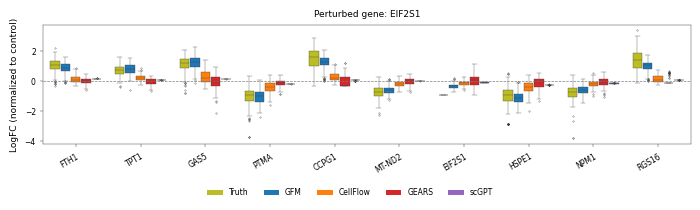

In [ ]:
model_name_list=['Truth', 'GFM', 'CellFlow', 'GEARS', 'scGPT']

plot_delta_expression_boxplot_model(
    adata,
    condition,
    model_name_list=model_name_list,
    palette=model_color_dict,
    top_n=10,
    save_path=f"../data/final_plots/{dataset}_delta_expression_boxplot_models_{condition}_{split}.pdf"
    )

## two-gene perturbation

In [ ]:
import pickle
# split results by subgroup
for split in [1, 2, 3]:
    method = 'gfm'
    working_dir = f"../data/{method}/norman_combo/split_{split}/"
    result_df = pd.read_csv(f"{working_dir}/results_test_gfm_go+ppi.csv")
    split_dict_subgroup = pickle.load(open(f"../data/gears/norman_combo/splits/norman_combo_simulation_{split}_0.75_subgroup.pkl", "rb"))
    
    for key in split_dict_subgroup['test_subgroup'].keys():
        conds = split_dict_subgroup['test_subgroup'][key]
        sub_res = result_df[result_df['condition'].isin(conds)]
        sub_res.to_csv(f"{working_dir}/results_test_gfm_go+ppi_{key}.csv", index=False)

In [ ]:
for split in [1, 2, 3]:
    split_dict_subgroup = pickle.load(open(f"../data/gears/norman_combo/splits/norman_combo_simulation_{split}_0.75_subgroup.pkl", "rb"))
    for method in ['cellflow', 'scgpt', 'gears', 'linear_model', 'pert_train', 'pos_ctrl']:
        working_dir = f"../data/{method}/norman_combo/"
        result_df = pd.read_csv(f"{working_dir}/results_test_{split}.csv")
        
        for key in split_dict_subgroup['test_subgroup'].keys():
            conds = split_dict_subgroup['test_subgroup'][key]
            sub_res = result_df[result_df['condition'].isin(conds)]
            sub_res.to_csv(f"{working_dir}/results_test_{key}_{split}.csv", index=False)

In [5]:
subgroup_names = ['combo_seen0', 'combo_seen1', 'combo_seen2']
splits = [1, 2, 3]

restults_list = []
test_results_list = []
for subgroup in subgroup_names:
    if subgroup != 'combo_seen2':
        result_dict = {
            "Dup": [f"../data/pos_ctrl/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
            "GFM": [f"../data/gfm/norman_combo/split_{split}/results_test_gfm_go+ppi_{subgroup}.csv" for split in splits],
            "Linear": [f"../data/linear_model/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
            "CellFlow": [f"../data/cellflow/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
            "GEARS": [f"../data/gears/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
            "scGPT": [f"../data/scgpt/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
            "Perturb train": [f"../data/pert_train/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
        }
    else:
        result_dict = {
            "Dup": [f"../data/pos_ctrl/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
            "Additive": [f"../data/additive_model/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
            "GFM": [f"../data/gfm/norman_combo/split_{split}/results_test_gfm_go+ppi_{subgroup}.csv" for split in splits],
            "Linear": [f"../data/linear_model/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
            "CellFlow": [f"../data/cellflow/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
            "GEARS": [f"../data/gears/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
            "scGPT": [f"../data/scgpt/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
            "Perturb train": [f"../data/pert_train/norman_combo/results_test_{subgroup}_{split}.csv" for split in splits],
        }

    res_dict = combine_results(result_dict, baseline_model="Perturb train", return_test_results=True)
    result_combined = res_dict['combined_results']
    result_combined['subgroup'] = subgroup
    restults_list.append(result_combined)

    test_results = res_dict['test_results']
    test_results['subgroup'] = subgroup
    test_results_list.append(test_results)

results_all = pd.concat(restults_list, ignore_index=True)
test_results_all = pd.concat(test_results_list, ignore_index=True)

In [6]:
from matplotlib.patches import Patch
def plot_metric_boxplot_grid(
    df,
    test_df,
    subgroup_names,
    metrics,
    figsize=None,
    model_color_dict=None,
    save_path=None,
    showfliers=False,
    baseline_zero_line=True,
    reference_model='GFM',
):
    """
    Create a grid of metric boxplots with metrics as rows and subgroups as columns.
    """
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    df = df.copy()

    metric_labels = {
        'mse': 'Δ MSE',
        'pearson': 'Δ Pearson Correlation',
        'pearson_delta': 'Pearson Delta',
        'spearman': 'Δ Spearman Correlation',
        'mmd': 'Δ MMD',
        'w2d': 'Δ 2-WD',
        'e_distance': 'Δ E-Distance',
    }

    n_metrics = len(metrics)
    n_subgroups = len(subgroup_names)

    if figsize is None:
        figsize = (6, 10)

    fig, axes = plt.subplots(n_metrics, n_subgroups, figsize=figsize, squeeze=False)

    model_name_list = df['model'].unique().tolist()

    for i, metric in enumerate(metrics):
        for j, subgroup in enumerate(subgroup_names):
            ax = axes[i, j]
            to_plot = df[df['subgroup'] == subgroup].copy()

            if metric in ['mmd', 'w2d', 'e_distance'] and 'model' in to_plot.columns:
                to_plot = to_plot[~to_plot['model'].isin(['Additive', 'Linear'])].copy()


            model_order = list(pd.unique(to_plot['model']))

            sns.boxplot(
                data=to_plot,
                x='model',
                y=metric,
                hue='model',
                order=model_order,
                hue_order=model_order,
                dodge=False,
                fill=True,
                width=0.6,
                linewidth=0.5,
                fliersize=0.0 if not showfliers else 2.0,
                palette=model_color_dict,
                saturation=1,
                ax=ax,
            )

            if baseline_zero_line:
                ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)

            # Match delta-metric style by hiding x labels in dense subplot grids.
            ax.set_xticklabels([])
            ax.set_xlabel('')

            if i == 0:
                ax.set_title(subgroup.replace('_', ' ').title(), fontweight='bold')

            if j == 0:
                ax.set_ylabel(metric_labels.get(metric, metric))
            else:
                ax.set_ylabel('')

            # Rescale each subplot to whisker range (exclude outliers), similar to
            # `plot_delta_metrics_boxplot`.
            groups = to_plot.groupby('model', observed=True)[metric]
            whisker_min = float('inf')
            whisker_max = float('-inf')
            model_top = {}

            for model_name, group_data in groups:
                data = group_data.dropna()
                if len(data) == 0:
                    continue
                q1 = data.quantile(0.25)
                q3 = data.quantile(0.75)
                iqr = q3 - q1
                lower_bound = q1 - 1.5 * iqr
                upper_bound = q3 + 1.5 * iqr
                actual_lower = data[data >= lower_bound].min()
                actual_upper = data[data <= upper_bound].max()
                whisker_min = min(whisker_min, actual_lower)
                whisker_max = max(whisker_max, actual_upper)
                model_top[model_name] = actual_upper

            if whisker_min != float('inf') and whisker_max != float('-inf'):
                if metric in ['pearson', 'pearson_delta', 'spearman']:
                    whisker_max = min(whisker_max, 1.0)
                y_range = whisker_max - whisker_min
                if y_range == 0:
                    y_range = max(abs(whisker_max), 1e-3)
                padding = 0.1 * y_range
                ax.set_ylim(whisker_min - padding, whisker_max + padding)
            else:
                y_range = 1.0

            # Add significance annotations like plot_delta_metrics_boxplot.
            if test_df is not None and not test_df.empty:
                metric_results = test_df[
                    (test_df['subgroup'] == subgroup) &
                    (test_df['metric'] == metric)
                ]

                if not metric_results.empty:
                    for model_idx, model_name in enumerate(model_order):
                        if model_name == reference_model:
                            continue

                        sig_row = metric_results[metric_results['comparison_model'] == model_name]
                        if sig_row.empty:
                            continue

                        sig_star = sig_row.iloc[0]['significance']
                        if sig_star == 'ns':
                            continue

                        y_pos = model_top.get(model_name, np.nan)
                        if pd.isna(y_pos):
                            continue

                        y_pos = y_pos + 0.02 * y_range
                        ymin, ymax = ax.get_ylim()
                        if y_pos >= ymax:
                            ax.set_ylim(ymin, y_pos + 0.05 * y_range)

                        ax.text(
                            model_idx + 0.05,
                            y_pos,
                            sig_star,
                            ha='center',
                            va='bottom',
                            fontweight='bold',
                        )

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    legend_elements = [Patch(facecolor=model_color_dict[model_name], label=model_name) for model_name in model_name_list]

    fig.legend(
        handles=legend_elements,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.05),
        ncol=len(model_name_list),
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

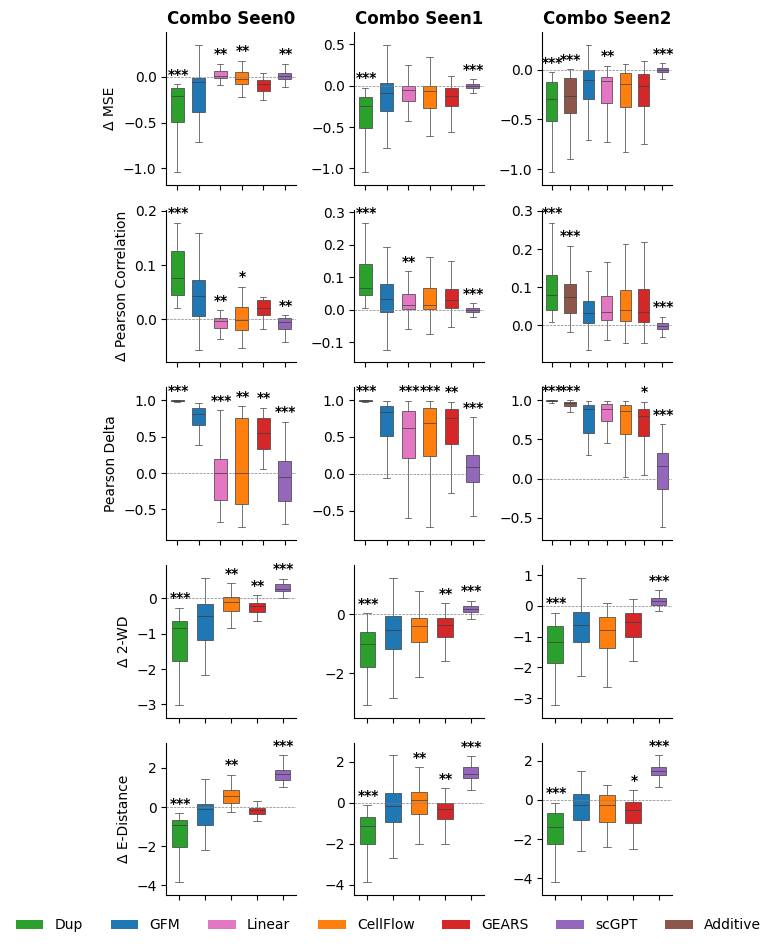

In [7]:
plot_metric_boxplot_grid(
    results_all,
    test_results_all,
    subgroup_names=subgroup_names,
    metrics=['mse', 'pearson', 'pearson_delta', 'w2d', 'e_distance'],
    model_color_dict=model_color_dict,
    save_path="../data/final_plots/test_metrics_boxplot_norman_combo_grid.pdf"
    )

In [ ]:
split = 1
dataset = 'norman_combo'
condition = 'CBL+PTPN9'
adata_paths = {
    "Truth": f"../data/preprocessed_{dataset}.h5ad",
    "GFM": f"../data/gfm/{dataset}/split_{split}/adata_pred_gfm_go+ppi.h5ad",
    "CellFlow": f"../data/cellflow/{dataset}/adata_pred_{split}.h5ad",
    "GEARS": f"../data/gears/{dataset}/adata_pred_{split}.h5ad",
    "scGPT": f"../data/scgpt/{dataset}/adata_pred_{split}.h5ad"
}

In [ ]:
adata = get_adata_condition_subset(adata_paths, condition=condition)

In [ ]:
adata.write_h5ad(f"../data/final_plots_data/adata_subset_{dataset}_{condition}_{split}.h5ad")

In [ ]:
adata = sc.read_h5ad(f"../data/final_plots_data/adata_subset_{dataset}_{condition}_{split}.h5ad")

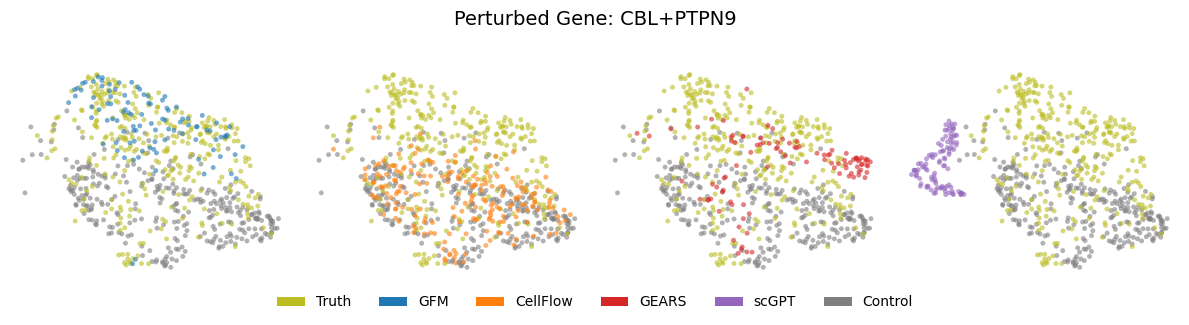

In [ ]:
plot_umap_by_model(adata, adata_paths, model_color_dict, condition=condition, figsize=(12, 3), size = 50,
                   save_path=f"../data/final_plots/{dataset}_umap_models_{condition}_{split}.pdf"
                   )

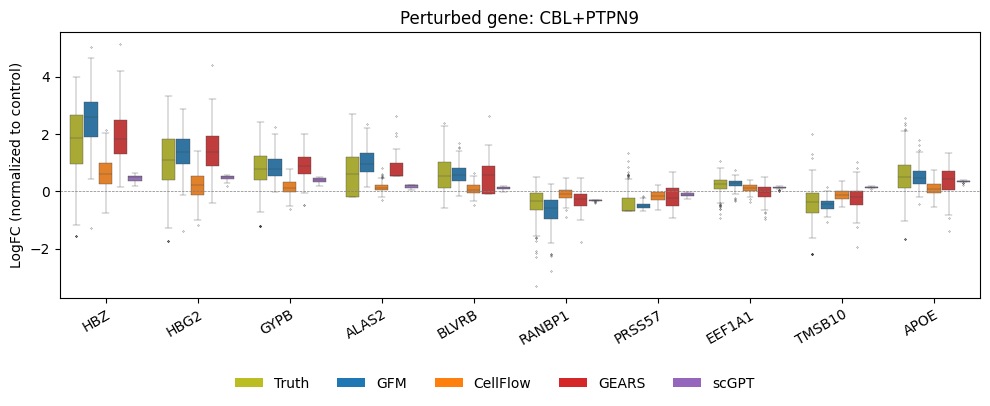

In [ ]:
model_name_list=['Truth', 'GFM', 'CellFlow', 'GEARS', 'scGPT']

plot_delta_expression_boxplot_model(
    adata,
    condition,
    model_name_list=model_name_list,
    palette=model_color_dict,
    top_n=10,
    figsize=(10, 4),
    save_path=f"../data/final_plots/{dataset}_delta_expression_boxplot_models_{condition}_{split}.pdf"
)